# Run infection dynamics with monoclonal killer T cell response

In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
# %config InlineBackend.figure_format = 'retina'
%load_ext line_profiler

### (1) Plot population averaged trajectories

In [2]:
# Set simulation parameters
N_0 = 100
K_IE = (10)*(10**4)
d_I = 1*d_S
infection_type = "sec" #"prim", "sec"
sim_type = "agent" #"pop_ode", "agent"
reg = psi_max*np.array([-0.5, -0.5, -0.0])

In [3]:
# %lprun -T lprof0 -f lin_stoch_sim lin_stoch_sim(N_0 = 100)

In [4]:
# Run single simulation
# %timeit -n 2 -r 2
data_dict = lin_stoch_sim(N_0 = N_0, b_I = b_I, 
                          K_IE = K_IE,
                          d_I = d_I,
                          K_IH = K_IH,
                          regulation_coeffs = reg,
                          infection = infection_type,
                          vir_model = "dep_harm",
                          out_data = "full")

In [5]:
regs = data_dict["reg_coeffs"]
dyn = data_dict["cell_time_series"]
ts = data_dict["time"]
lin_comp = data_dict["lineage_diff"]
p_diff = data_dict["prim_diff_bias"]
s_diff = data_dict["sec_diff_bias"]
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
Eff = data_dict["eff_by_lin"]
mycNa = data_dict["Na_myc_by_lin"]
mycMa = data_dict["Ma_myc_by_lin"]
mycE = data_dict["E_myc_by_lin"]
T_pEcytM = data_dict["pmemory_formed"]
T_sEcytM = data_dict["pmemory_survived"]

S, I, A, Na, E, M, H, I_d_I, I_d_S = dyn[:,-9], dyn[:,-8], dyn[:,-7], dyn[:,-6], dyn[:,-5], dyn[:,-4], dyn[:,-3], dyn[:,-2], dyn[:,-1]

reg_string = '-'.join((reg * 1).astype('U1'))

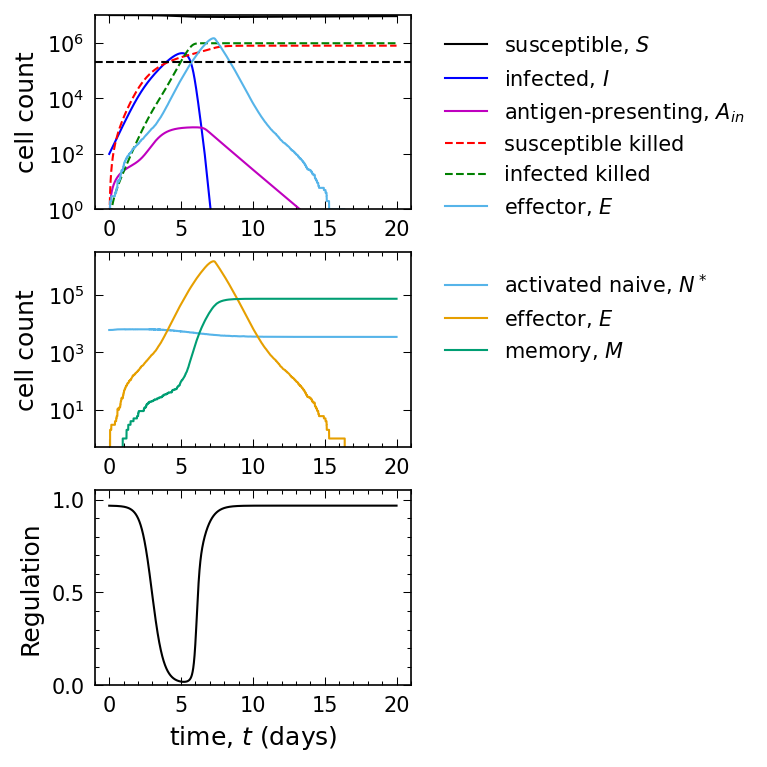

In [6]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(5,5))

ax1.plot(ts, S, 'k', label = r'susceptible, $S$')
ax1.plot(ts, I, 'b', label = r'infected, $I$')
ax1.plot(ts, A, 'm', label = r'antigen-presenting, $A_{in}$')
ax1.plot(ts, I_d_S, 'r', linestyle = '--', label = r'susceptible killed')
ax1.plot(ts, I_d_I, 'g', linestyle = '--', label = r'infected killed')
ax1.plot(ts, E, label = r'effector, $E$')
ax1.axhline(y = d_S/b_I, color = 'k', linestyle = '--')
ax1.set(ylabel='cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, Na, label = r'activated naive, $N^*$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, M, label = r'memory, $M$')
ax2.set(ylabel='cell count')
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, f_XtoY(I, H, psi_I = reg[0], psi_H = reg[1], psi_IH = reg[2]/2, F_0 = -np.sum(reg), K_I = K_EI, K_H = K_EH),
         'k-', label = r'Regulation, $f(I,H)$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='Regulation')
ax3.set_ylim(0,1.05)

fig.savefig("_figs/"+infection_type+'-'+'virus-effector dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

In [7]:
print(f'Memory fraction = {(np.max(M))/np.max(E)}')
print(f'Number of memory cells = {np.max(M)}')
print(f'1st infection harm = {sim_summary[4]/(d_S*S_0)}')
print(f'2nd infection harm = {sim_summary[5]/(d_S*S_0)}')
print(f'1st response harm = {sim_summary[6]/(d_S*S_0)}')
print(f'2nd response harm = {sim_summary[7]/(d_S*S_0)}')
print(f'Minimum susceptible = {np.min(S)/S_0}')

Memory fraction = 0.049542500958381024
Number of memory cells = 72630.0
1st infection harm = 15.723828017950803
2nd infection harm = 1.9381031546574048
1st response harm = 1.4292062651698105
2nd response harm = 1.5829721776718046
Minimum susceptible = 0.8525111324286161


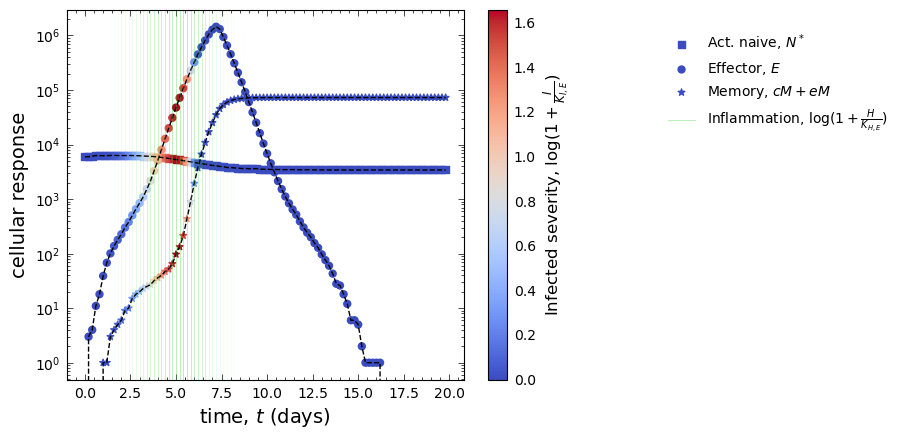

In [8]:
# Plot simulated infection dynamics: pretty plots
pnts = 100
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
sus = S[keep]
naive = Na[keep]
eff = E[keep]
mem = M[keep]
p_load = np.log(1 + I[keep]/K_IE)
inflam = np.log(1 + H[keep]/K_EH)/8
time = ts[keep]

plt.scatter(time, naive, marker ='s', c = p_load, cmap='coolwarm', 
            label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
plt.plot(time, naive, 'k--')
plt.scatter(time, eff, marker ='o', c = p_load, cmap='coolwarm', 
            label = r'Effector, $E$') #, norm=mpl.colors.LogNorm())
plt.plot(time, eff, 'k--')
plt.scatter(time, mem, marker ='*', c = p_load, cmap='coolwarm',
            label = r'Memory, $cM+eM$') #, norm=mpl.colors.LogNorm())
plt.plot(time, mem, 'k--')

plt.colorbar(label =r"Infected severity, $\log(1 + \frac{I}{K_{I,E}})$")
plt.ylabel('cellular response', fontsize = 14)
plt.xlabel(r"time, $t$ (days)", fontsize = 14)
plt.semilogy()

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $\log(1 + \frac{H}{K_{H,E}})$")
    else:
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])

plt.legend(loc='center right', bbox_to_anchor=(2.1, 0.8), fontsize = 10)

plt.savefig('_figs/'+infection_type+'-timeline-of-infection-dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

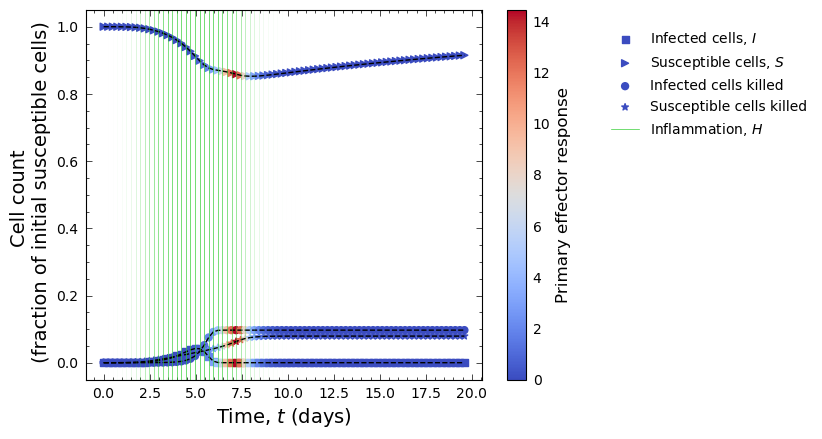

In [9]:
# Plot simulated infection dynamics: pretty plots of harm
pnts = 80
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]

eff = E[keep]
p_load = I[keep]/S_0
sus = S[keep]/S_0
inf_harm = I_d_I[keep]/S_0
inflam_harm = I_d_S[keep]/S_0
inflam = H[keep]**l_H/(K_EH**l_H + H[keep]**l_H)
time = ts[keep]

plt.scatter(time, p_load, marker ='s', c =eff/K_IE, cmap='coolwarm', 
            label = r'Infected cells, $I$') #, norm=mpl.colors.LogNorm())
plt.plot(time, p_load, 'k--')

plt.scatter(time, sus, marker ='>', c =eff/K_IE, cmap='coolwarm', 
            label = r'Susceptible cells, $S$') #, norm=mpl.colors.LogNorm())
plt.plot(time, sus, 'k--')

plt.scatter(time, inf_harm, marker ='o', c =eff/K_IE, cmap='coolwarm', 
            label = 'Infected cells killed')
plt.plot(time, inf_harm, 'k--')

plt.scatter(time, inflam_harm, marker ='*', c =eff/K_IE, cmap='coolwarm',
            label = 'Susceptible cells killed')
plt.plot(time, inflam_harm, 'k--')

plt.colorbar(label = "Primary effector response")
plt.ylabel('Cell count \n (fraction of initial susceptible cells)', fontsize = 14)
plt.xlabel(r"Time, $t$ (days)", fontsize = 14)

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
    else:
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])
        
plt.legend(loc='center right', bbox_to_anchor=(1.85, 0.8), fontsize = 10)
plt.savefig('_figs/'+infection_type+'-infection-harm-'+reg_string+'.png', dpi=300, bbox_inches="tight")

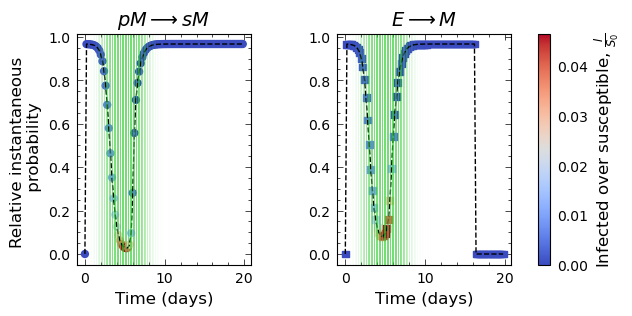

In [10]:
# Plot simulated infection dynamics: pretty plots
pnts = 100
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
bias_diff = p_diff[keep] if infection_type == "prim" else s_diff[keep]
p_load = I[keep]
sus = S[keep]
inflam =  H[keep]**l_H/(K_EH**l_H + H[keep]**l_H)
time = ts[keep]

fig, axs = plt.subplots(1,2, figsize=(7,3))

if infection_type == "prim":
    im1 = axs[0].scatter(time, bias_diff[:,0], marker = 's', c =p_load/S_0, cmap='coolwarm', 
                label = r'$N^* \longrightarrow M$')
    axs[0].plot(time, bias_diff[:,0],'k--')
    axs[0].title.set_text(r'$N^* \longrightarrow M$')

elif infection_type == "sec":
    im1 = axs[0].scatter(time, bias_diff[:,2], marker = 'o', c =p_load/sus, cmap='coolwarm', 
                label = r'$M$')
    axs[0].plot(time, bias_diff[:,2],'k--')
    axs[0].title.set_text(r'$pM \longrightarrow sM$')

im3 = axs[1].scatter(time, bias_diff[:,1], marker = 's', c =p_load/sus, cmap='coolwarm', 
            label = r'$E \longrightarrow M$')
axs[1].plot(time, bias_diff[:,1],'k--')
axs[1].title.set_text(r'$E \longrightarrow M$')

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        axs[0].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
        axs[1].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
    else:
        axs[0].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])
        axs[1].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")


axs[0].set(ylabel='Relative instantaneous \n probability', 
           xlabel="Time (days)")
axs[1].set(ylabel='', 
           xlabel="Time (days)")

fig.subplots_adjust(wspace=.5)
cb = fig.colorbar(im1, ax=axs, orientation='vertical')
cb.set_label(r"Infected over susceptible, $\frac{I}{S_0}$")

#cb.set_clim(-0.4,0.4)
    
# plt.colorbar(label =r"pathogen load, $I(t)$")
# plt.ylabel('transition weight', fontsize = 16)
# plt.xlabel("time (days)", fontsize = 16)
# plt.legend() #bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.savefig('_figs/'+infection_type+'-diff-bias-over-time-'+reg_string+'.png', dpi=300, bbox_inches="tight")

### (2) Plot lineage-based trajectories

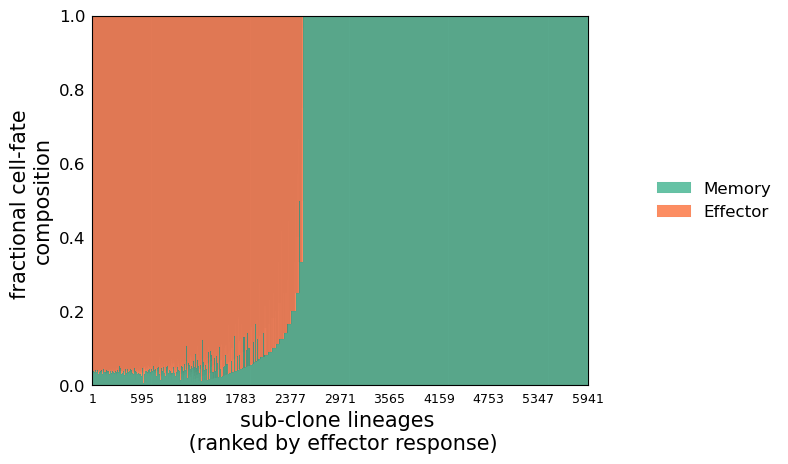

In [11]:
keys = np.array(['Memory', 'Effector'])
all_counts = lin_comp[1:3].T
effector_ranking = np.argsort(all_counts[:, 1])[::-1]
all_counts = all_counts[effector_ranking]
total_counts = all_counts.sum(axis=1)
norm_counts = all_counts / total_counts[:, None]
norm_counts[~np.isfinite(norm_counts)] = 0
comp_argsort = np.argsort(np.max(all_counts, axis=0))
bar_dict = {k: v for k, v in zip(keys[comp_argsort], norm_counts.T[comp_argsort])}
lineage_idxs = np.arange(all_counts.shape[0])

fig, ax = plt.subplots()
bottom = np.zeros(len(lineage_idxs))
cmap_colors = sns.color_palette('Set2', 10)
cmap_colors = [cmap_colors[i]
               for i in [0, 1, 5]]#[7, 2, 0, 1, 5]]
# cmap_colors = [cmap_colors[i]
#                for i in [6, 1, 2, 5, 0]]
width = 1

for i, (celltype, fraction) in enumerate(bar_dict.items()):
    ax.bar(lineage_idxs, fraction, width,
           edgecolor='k', linewidth=0.01,
           label=celltype, bottom=bottom, color=cmap_colors[i])
    bottom += fraction
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize = 12)
ax.set_xlim(-0.5, len(all_counts) - 0.5)
ax.set_xlabel('sub-clone lineages \n (ranked by effector response)', fontsize = 15)
ax.set_ylabel('fractional cell-fate \ncomposition', fontsize = 15)
#ax.set_yscale('log')

ax.set_xticks(np.arange(0, Eff.shape[1], int(Eff.shape[1]/10)))
ax.set_xticklabels(1 + np.arange(0, Eff.shape[1], int(Eff.shape[1]/10)), fontsize=9)

ax.set_yticks(np.round(np.arange(0, 1.2, 0.2), 1))
ax.set_yticklabels(ax.get_yticks(), fontsize=12)

fig.savefig("_figs/"+infection_type+'-'+'fates-by-lin-'+reg_string+'.png', dpi=300, bbox_inches="tight")


[]

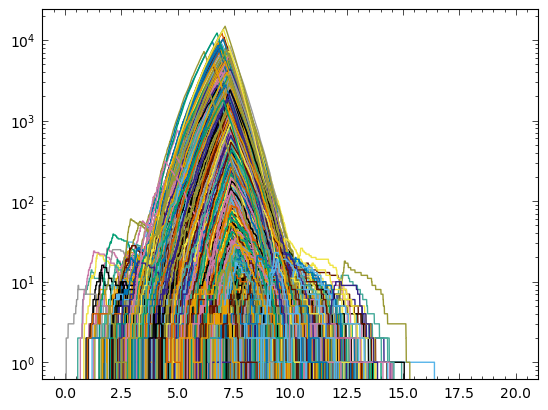

In [12]:
plt.plot(ts, Eff)
plt.semilogy()

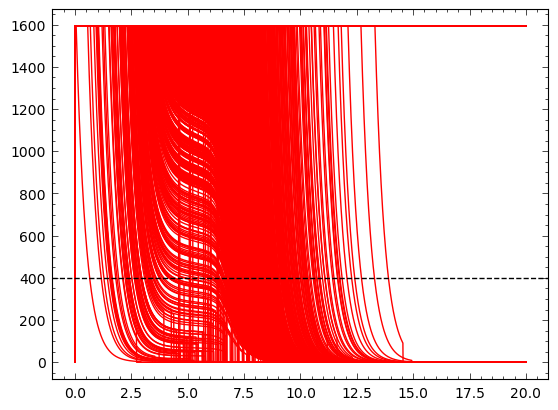

In [13]:
plt.plot(ts, mycE, 'r-')
#plt.plot(ts, mycMa, 'k-')
plt.axhline(y = myc_thresh, color = 'k', linestyle = '--')
#plt.semilogy()

In [14]:
np.sum(np.max(mycE, axis=0) < myc_thresh)/N_0

0.0

0.3601623062015504


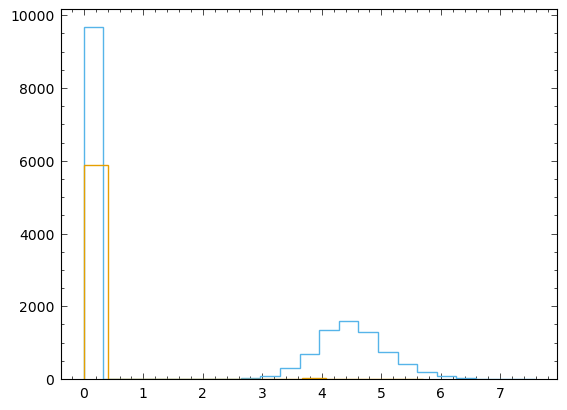

In [21]:
#plt.hist(np.argmax(mycNa > 0, axis = 0)*sim_duration/sim_steps, bins='auto')
plt.hist(T_pEcytM, bins='auto', histtype='step');
plt.hist(T_sEcytM, bins='auto', histtype='step');
print(len(T_sEcytM)/len(T_pEcytM))

Text(0.5, 0.98, 'Peak response response: $N_0=$ 100, $d_I=$0.05')

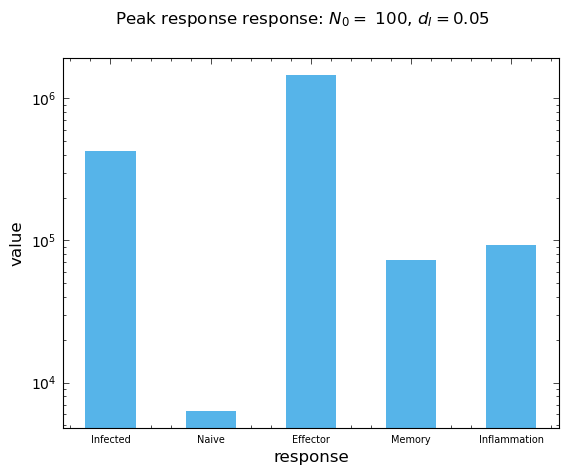

In [16]:
# Compute max values in the data
r = np.arange(5)
width = 0.5
plt.bar(r, np.amax(np.array([I, Na, E, M, H]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Memory", "Inflammation"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $N_0=$ '+str(N_0) +r', $d_I=$'+str(d_I))
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'peak-response'+'.png', dpi=150)

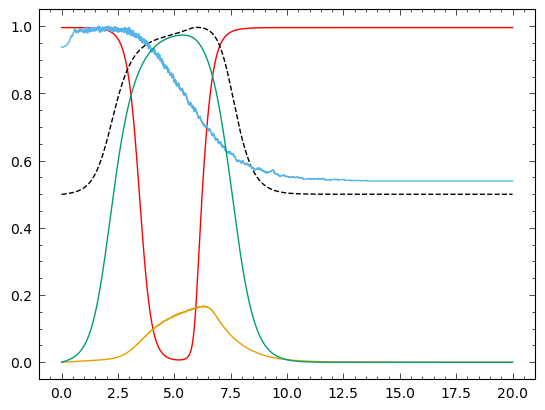

In [17]:
bias_1 = f_XtoY(I, H, 
       -2.0, -2.0, 0.0, F_0 = 4*np.log(2), 
       K_I = K_IE, K_H = K_EH)
bias_2 = f_XtoY(I, H, 
       -2.0, 2.0, 0.0, F_0 = -0*np.log(2), 
       K_I = K_IE, K_H = K_EH)

plt.plot(ts, bias_1, 'r')
plt.plot(ts, bias_2, 'k--')
plt.plot(ts, Na/np.amax(Na))
plt.plot(ts, A/(Na + A))
plt.plot(ts, H**l_H/(K_EH**l_H + H**l_H))

In [19]:
# runs = 1
# vir_samp = np.tile(vir_prop, (runs,1))
# d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/"

# run(reg_opt = [1043], outdir=d, virus_sample = vir_samp, comment="lin-based")

In [ ]:
[0.5, -0.5, 0.0, 0.0, 0.0, 1.0, 0.5, -0.5, 0.0]
d_file = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/1.0--1.0-0.0-0.0-0.0-2.0-1.0--1.0-0.0-200-sec--ncv.pkl'
with open(d_file, 'rb') as f:   
    out = pickle.load(f)

In [ ]:
dyn_data = out["cell_time_series"][4]
ts = out["time"][4]
print(out["sumary_stats"][4])
pS, sS, pI, sI, sAin, sN, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,0], dyn_data[:,-10], dyn_data[:,1], dyn_data[:,-9], dyn_data[:,-8], dyn_data[:,3], dyn_data[:, 4], dyn_data[:,-6], dyn_data[:,5], dyn_data[:, -5], dyn_data[:,6], dyn_data[:,-4], dyn_data[:,7], dyn_data[:,-3], dyn_data[:,8], dyn_data[:,-2], dyn_data[:,9], dyn_data[:,-1]

In [ ]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(5,5))

ax1.plot(ts, pS, 'k', label = r'susceptible, $S$')
ax1.plot(ts, pI, 'b', label = r'infected, $I$')
ax1.plot(ts, A, 'm', label = r'antigen-presenting, $A_{in}$')
ax1.plot(ts, I_d_S, 'r', linestyle = '--')
ax1.plot(ts, I_d_I+I_d_S, 'g', linestyle = '--')
ax1.axhline(y = 0.5*S_0, color = 'k', linestyle = '--')
ax1.axhline(y = 0.01*d_S*S_0, color = 'y', linestyle = '--')
ax1.set(ylabel='cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, Na, label = r'activated naive, $N^*$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, cM, label = r'central memory, $cM$')
ax2.plot(ts, eM, label = r'effector memory, $eM$')
ax2.set(ylabel='cell count')
ax2.set_ylim(10,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, H,'k-', label = r'inflammation, $H$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='cell count')
#ax3.semilogy()
#ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

In [ ]:
n = int(num_categories/2) + 1
fig, axs = plt.subplots(n_virs+1,n, figsize=(2*n + 4, 2*(n_virs+1)), sharex=True, sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(chosen_virs)):

    for i, category in enumerate(perf_categories[:5]):
        k = np.where((vir_prop[:,0] == d_I)*(vir_prop[:,1] == K_IE))[0].item()
        diff_index = i + num_categories*k
        
        p_data = np.array(p_diff_data_for_dmd[diff_index])
        dyn_data = np.array(dyn_data_for_dmd[diff_index])
        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,:,0], dyn_data[:,:,-10], dyn_data[:,:,1], dyn_data[:,:,-9], dyn_data[:,:,-8], dyn_data[:,:,-7], dyn_data[:,:, 4], dyn_data[:,:,-6], dyn_data[:,:,5], dyn_data[:,:, -5], dyn_data[:,:,6], dyn_data[:,:,-4], dyn_data[:,:,7], dyn_data[:,:,-4], dyn_data[:,:,8], dyn_data[:,:,-2], dyn_data[:,:,9], dyn_data[:,:,-1]

            im = axs[l,i].scatter(time, np.mean(N, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='s', cmap='coolwarm', 
            label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
            axs[l,i].plot(time, np.mean(N, axis = 0), 'k--')
            
            axs[l,i].scatter(time, np.mean(pE, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='o', cmap='coolwarm', 
                        label = r'Effector, $E$')
            axs[l,i].plot(time, np.mean(pE, axis = 0), 'k--')
            
            axs[l,i].scatter(time, np.mean(pcM + peM, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='*', cmap='coolwarm',
                        label = r'Memory, $cM+eM$')
            axs[l,i].plot(time, np.mean(pcM + peM, axis = 0), 'k--')

            axs[l,i].semilogy()
            
            [axs[l,i].axvline(x=time[j], linestyle='-', linewidth=0.3, color='limegreen', alpha=np.mean(pH[:,j])/(K_EH + np.mean(pH[:,j])), zorder = 0) for j in np.arange(0, pnts-1)]
        
                
        if i == 0:
            axs[l,0].set_ylabel(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(np.round(K_IE/K_SE,3))+r"$\times K_{S,E}$", fontsize = 10)
        
        if l == 0:
            if i == 0:
                axs[0,i].set_title('Biologically \n motivated', fontsize = 8)
            else:
                axs[0,i].set_title(r'Top '+str(int((1-cutoff)*100))+'%'+' in \n'+perf_labels[i-1], fontsize = 8)

axs[0,0].axvline(x=time[np.argmax(np.mean(pH, axis = 0))], linestyle='-', linewidth=0.3, color='limegreen', alpha=np.max(np.mean(pH, axis = 0))/(K_EH + np.max(np.mean(pH, axis = 0))), label =r"Inflammation, $H$")
axs[0,0].legend(loc='center right', bbox_to_anchor=(7.5, 0.7), fontsize = 14)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.05)
cb.set_label("Infection load", fontsize = 12)

for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"time, $t$ (days)", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()

plt.savefig('_figs/mean_cell_dynamics_by_category', dpi=300, bbox_inches='tight')

In [ ]:
x_all = np.array(list(itertools.product([-1,-0.5, 0, 0.5, 1], repeat =3)))
x_contr = x_all[(np.sum(np.abs(x_all), axis = 1) == 1) + (np.sum(np.abs(x_all), axis = 1) == 0)]

In [ ]:
vir_prop = np.vstack((np.array([0, K_SE, 1.0, 1.0]), # autoimmune situation
                       np.array(np.meshgrid(d_S*np.array([2, 5, 10]), # vary d_I
                                            K_IE*np.array([1, 5, 10]), # vary K_IE
                                            np.array([0.1,1.0]), # vary K_EI
                                            np.array([0.1,1.0]))).T.reshape(-1,4))) # vary K_EH